# Entwicklung der Menschenrechte weltweit: Veränderungen im Human Rights Index (1950-2024)
## Abgabetermin
Datum: **15. Dezember 2025**
## Gruppenmitglieder
### Alessandro Zandt 
E-Mail: zandtale@students.zhaw.ch
### David Hascher
E-Mail: haschdav@students.zhaw.ch
### Tauland Strellci
E-Mail: streltau@students.zhaw.ch
## Kurzer Projektbeschrieb
In diesem Projekt analysieren wir die zeitliche Entwicklung des Human Rights Index für verschiedene Länder.
Der Datensatz Human Rights Index von V-Dem misst, wie stark grundlegende Menschenrechte in einzelnen Ländern geschützt sind. Der Index basiert auf Expertenschätzungen und umfasst zentrale Bereiche wie:

- Schutz vor staatlicher Gewalt (Tortur, politische Morde, Zwangsarbeit)

- Rechte auf Eigentum

- Bewegungsfreiheit

- Religionsfreiheit

- Meinungs- und Pressefreiheit

- Vereinigungsfreiheit

Der Index reicht von 0 bis 1, wobei 1 ein sehr hohes Schutzniveau der Menschenrechte darstellt.


### Datensatz
Quelle: https://ourworldindata.org/vdem-human-rights-data
### Fragestellung

<span style="color:red; font-weight:bold"> Wie haben sich die Menschenrechte in verschiedenen Ländern in den letzten Jahren entwickelt, und welche drei Staaten verzeichnen die stärksten Verbesserungen bzw. Verschlechterungen zwischen 1950 und 2024?</span>



## 1. Daten beschaffen und laden

- Den Datensatz konnten wir in passender Form direkt von der Webseite "OurWorldinData" herunterladen

In [5]:
# Daten geladen
import pandas as pd
from matplotlib import pyplot as plt
import requests

# Fetch the data.
df = pd.read_csv("https://ourworldindata.org/grapher/human-rights-index-vdem.csv?v=1&csvType=full&useColumnShortNames=true", storage_options = {'User-Agent': 'Our World In Data data fetch/1.0'})

# Fetch the metadata
metadata = requests.get("https://ourworldindata.org/grapher/human-rights-index-vdem.metadata.json?v=1&csvType=full&useColumnShortNames=true").json()

In [6]:
df.head()

,Entity,Code,Year,civ_libs_vdem__estimate_best,owid_region
0,Afghanistan,AFG,1789,0.121,NaN
1,Afghanistan,AFG,1790,0.121,NaN
2,Afghanistan,AFG,1791,0.121,NaN
3,Afghanistan,AFG,1792,0.121,NaN
4,Afghanistan,AFG,1793,0.121,NaN


## 2. Daten vorbereiten


Die Daten wären noch nicht in einem passenden Format. Wir nutzten den df.head()-Befehl um die ersten 5 Zeilen darzustellen. Darauf Basierend fällten wir Entscheidungen über mögliche modifikationen.
- Wir entschieden uns, dass die Spaltennamen auf Deutsch darzustellen und eine ganze Spalte nicht anzeigen zu lassen.

In [7]:
df = pd.read_csv(
    "https://ourworldindata.org/grapher/human-rights-index-vdem.csv?v=1&csvType=full&useColumnShortNames=true"
)

# Spalten hatten seltsame Namen, Namen geändert
df = df.rename(columns={
    "Entity": "Land",
    "Code": "Kürzel",
    "Year": "Jahr",
    "civ_libs_vdem__estimate_best": "Human Rights Index"
})

# Unnötige Spalte 'owid_region' noch entfernt
df = df.drop(columns=["owid_region"], errors="ignore")
df.head()


,Land,Kürzel,Jahr,Human Rights Index
0,Afghanistan,AFG,1789,0.121
1,Afghanistan,AFG,1790,0.121
2,Afghanistan,AFG,1791,0.121
3,Afghanistan,AFG,1792,0.121
4,Afghanistan,AFG,1793,0.121


<span style="color:red; font-weight:bold"> Dies ist nun eine sinnvoll angepasste Tabelle für unser Projekt!</span>


### Format des Datensatz
- Die Daten werden im **Long Format** dargestellt.
- Der Human Rights Index und das Land stehen in einer seperaten Spalte und sind als **Werte** angegeben.


- Wir haben in underem Projekt das **Long Format** und **Pivot Format** benutzt.
- Long Format: Dieses nutzen wir für das grobe analysieren der Daten.
- Pivot Format: Durch das erhalten wir unsere Daten im **Wide Format**, nutzen können wir dies für direkte vergleiche zum Beispiel in einem Land.


### Datentypen
- In unserem Datensatz kommen verschiedene Datentypen vor.  
- Durch den Befehl `df.info()` konnten wir diese darstellen.  

Unsere Datentypen:

- Land - object
- Kürzel - objekt
- Jahr - int64
- Human Right Index - float64


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34850 entries, 0 to 34849
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Land                34850 non-null  object 
 1   Kürzel              31870 non-null  object 
 2   Jahr                34850 non-null  int64  
 3   Human Rights Index  34753 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 1.1+ MB


## 3. Statistik der Roh-Daten (Analyse im Long-Format)


- Es handelt sich bei unserer Variable, dem Human Rights Index, um kontenuierliche Zahlen, denn sie enthält reelle Werte im Bereich 0–1, mit vielen Zwischenwerten.

- Anzahl der Datenpunkte


In [9]:
df['Human Rights Index'].count()
df[(df["Jahr"] >= 1950) & (df["Jahr"] <= 2024)].count()



Land                  14462
Kürzel                13353
Jahr                  14462
Human Rights Index    14365
dtype: int64

- Wo fehlen Datenpunkte?

In [10]:
df['Human Rights Index'].isna().sum()


np.int64(97)

Für jedes Land:

In [11]:

df.groupby('Land')['Human Rights Index'].apply(lambda x: x.isna().sum())


Land
Afghanistan                     0
Africa                          0
Africa (population-weighted)    0
Aland Islands                   1
Albania                         0
                               ..
Yemen People's Republic         1
Yugoslavia                      1
Zambia                          0
Zanzibar                        0
Zimbabwe                        0
Name: Human Rights Index, Length: 307, dtype: int64

Für jedes Jahr:

In [12]:
df.groupby('Jahr')['Human Rights Index'].apply(lambda x: x.isna().sum())


Jahr
1789     0
1790     0
1791     0
1792     0
1793     0
        ..
2020     0
2021     0
2022     0
2023    97
2024     0
Name: Human Rights Index, Length: 236, dtype: int64

- Verteilung der Variable (Histogram, Boxplot, Säulendiagramm)

Histogramm

<Axes: title={'center': 'Histogram: Verteilung des Human Rights Index'}, ylabel='Frequency'>

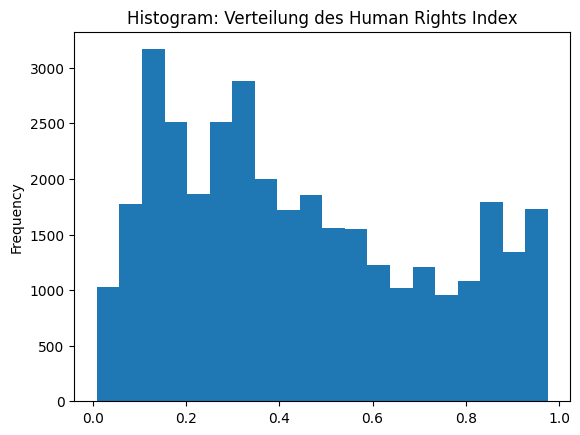

In [13]:
df['Human Rights Index'].plot.hist(
    bins=20,
    title="Histogram: Verteilung des Human Rights Index"
)


Boxplot

<Axes: title={'center': 'Boxplot des Human Rights Index'}>

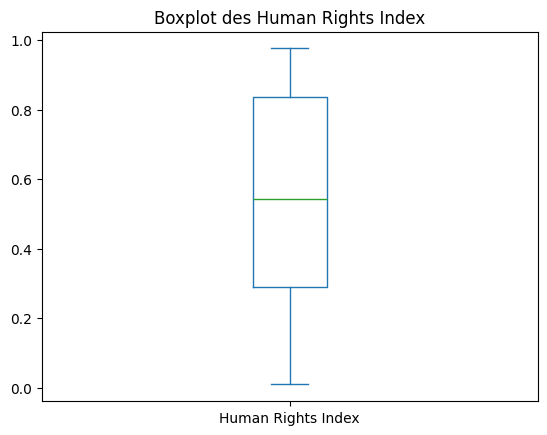

In [20]:
df[df["Jahr"].between(1950, 2024)]["Human Rights Index"].plot.box(
    title="Boxplot des Human Rights Index"
)


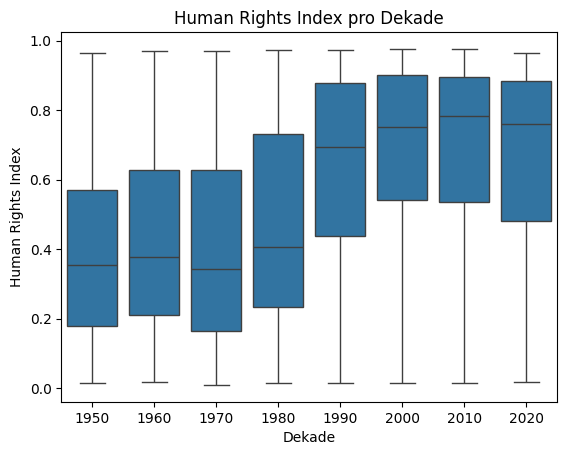

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

df['Dekade'] = (df['Jahr'] // 10) * 10

sns.boxplot(
    data=df[df['Jahr'].between(1950, 2024)],
    x='Dekade',
    y='Human Rights Index'
)

plt.title("Human Rights Index pro Dekade")
plt.show()


- Zusammenhänge zwischen Variablen

Variabeln: Jahr, Human Rights Index

Streuungsdiagramm (Scatter Plot)

<Axes: title={'center': 'Zusammenhang zwischen Jahr und Human Rights Index'}, xlabel='Jahr', ylabel='Human Rights Index'>

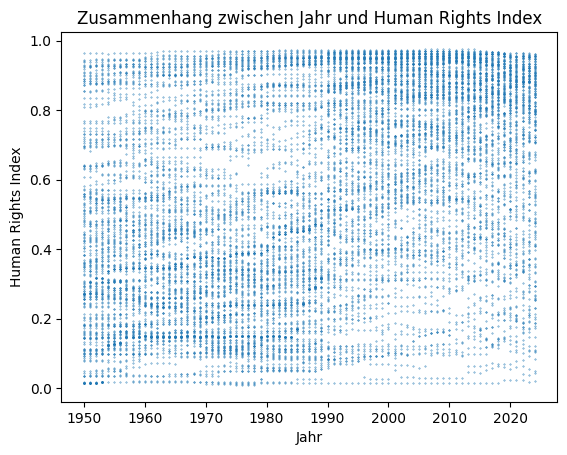

In [18]:


df[df["Jahr"].between(1950, 2024)].plot.scatter(
    x="Jahr",
    y="Human Rights Index",
    s=0.1,
    title="Zusammenhang zwischen Jahr und Human Rights Index"
)



Korrelationsmatrix

In [22]:
df[df['Jahr'].between(1950, 2024)][['Jahr', 'Human Rights Index']] \
    .corr() \
    .style.background_gradient(cmap='coolwarm')



,Jahr,Human Rights Index
Jahr,1.000000,0.383458
Human Rights Index,0.383458,1.000000


- Pivot-Tabelle zur ersten Visualisierung der Daten

<Axes: title={'center': 'Veränderung des Human Rights Index – Switzerland'}, xlabel='Jahr', ylabel='Human Rights Index'>

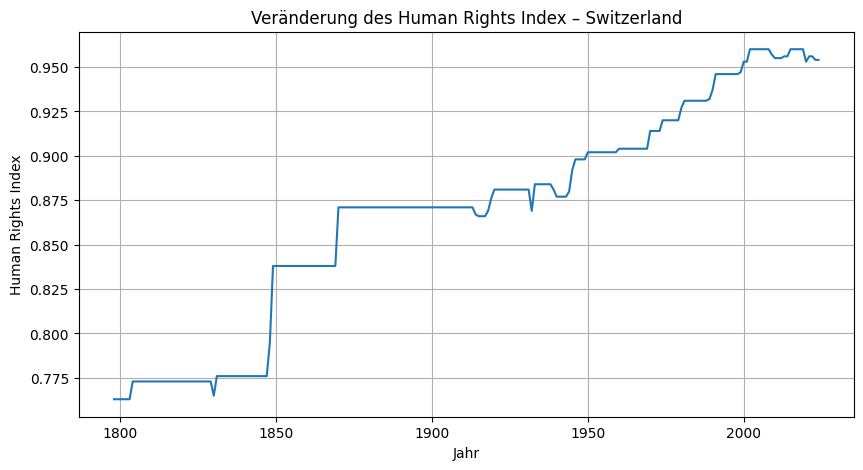

In [ ]:

pivot = df.pivot_table(
    index="Jahr",
    columns="Land",
    values="Human Rights Index"
)

# Land auswählen
land = "Switzerland"

pivot[land].plot(
    title=f"Veränderung des Human Rights Index – {land}",
    xlabel="Jahr",
    ylabel="Human Rights Index",
    grid=True,
    figsize=(10, 5)
)

- Pivot-Tabelle mit Dropdown

In [23]:
#  Daten auf Zeitraum 1950–2024 filtern
df_filtered = df[(df["Jahr"] >= 1950) & (df["Jahr"] <= 2024)]

pivot = df_filtered.pivot_table(
    index="Jahr",
    columns="Land",
    values="Human Rights Index"
)

# Dropdown 
import ipywidgets as widgets
from IPython.display import display

def plot_land(land):
    pivot[land].plot(
        title=f"Human Rights Index – {land} (1950–2024)",
        xlabel="Jahr",
        ylabel="Human Rights Index",
        grid=True,
        figsize=(10, 5)
    )

dropdown = widgets.Dropdown(
    options=sorted(pivot.columns),
    description="Land:",
    value=sorted(pivot.columns)[0] 
)

widgets.interact(plot_land, land=dropdown)

interactive(children=(Dropdown(description='Land:', options=('Afghanistan', 'Africa', 'Africa (population-weig…

<function __main__.plot_land(land)>

## 4. Analyse


### Visualisierung

**Fragestellung: Wie haben sich die Menschenrechte in verschiedenen Ländern in den letzten Jahren entwickelt, und welche drei Staaten verzeichnen die stärksten Verbesserungen bzw. Verschlechterungen zwischen 1950 und 2024?**

**Berechnen der Fragesellung spezifischen Daten.**

- Daten vorbereiten

In [ ]:

# Zeitraum filtern
df_filtered = df[(df["Jahr"] >= 1950) & (df["Jahr"] <= 2024)]

# Pivot-Tabelle: Jahre als Index, Länder als Spalten
pivot = df_filtered.pivot_table(
    index="Jahr",
    columns="Land",
    values="Human Rights Index"
)


- Berechnung der Veränderung 1950 bis 2024

In [ ]:
# Start- und Endwerte
start_values = pivot.loc[1950]
end_values = pivot.loc[2024]

# Differenz berechnen
diff = end_values - start_values

# 3 Länder mit stärkster Verbesserung
top_improvements = diff.sort_values(ascending=False).head(3)

# 3 Länder mit stärkster Verschlechterung
top_declines = diff.sort_values(ascending=True).head(3)

# Ausgabe als Pandas-Tabellen
import pandas as pd

print("📈 Die stärksten Verbesserungen (1950–2024):")
df_improve = pd.DataFrame({
    "Land": top_improvements.index,
    "Veränderung": top_improvements.values
})
display(df_improve)

print("📉 Die stärksten Verschlechterungen (1950–2024):")
df_decline = pd.DataFrame({
    "Land": top_declines.index,
    "Veränderung": top_declines.values
})
display(df_decline)



📈 Die stärksten Verbesserungen (1950–2024):


,Land,Veränderung
0,Estonia,0.945
1,Latvia,0.924
2,Lithuania,0.899


📉 Die stärksten Verschlechterungen (1950–2024):


,Land,Veränderung
0,Eritrea,-0.462
1,Myanmar,-0.454
2,Cuba,-0.430


**Visualisieren der Fragesellung spezifischen Daten.**

In [ ]:
# Wir wählen die Top 3 Verbesserungen / Top 3 Verschlechterungen
laender1 = list(top_improvements.index)
laender2 = list(top_declines.index)



- Stärkste Verbesserungen

<Axes: title={'center': 'Stärkste Verbesserungen im Human Rights Index (1950–2024)'}, xlabel='Jahr', ylabel='Human Rights Index'>

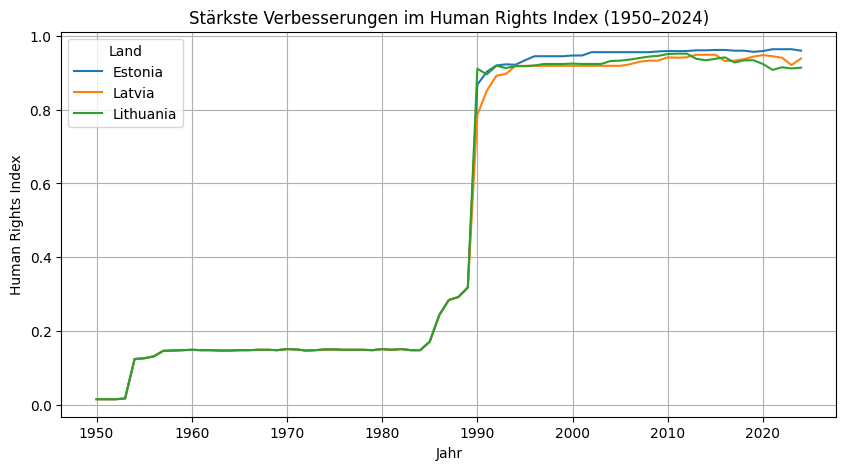

In [ ]:
# pivot enthält die Zeitreihen
pivot[laender1].plot(
    title="Stärkste Verbesserungen im Human Rights Index (1950–2024)",
    xlabel="Jahr",
    ylabel="Human Rights Index",
    grid=True,
    figsize=(10, 5)
)



- Stärkste Verschlechterungen

<Axes: title={'center': 'Stärkste Verschlechterungen im Human Rights Index (1950–2024)'}, xlabel='Jahr', ylabel='Human Rights Index'>

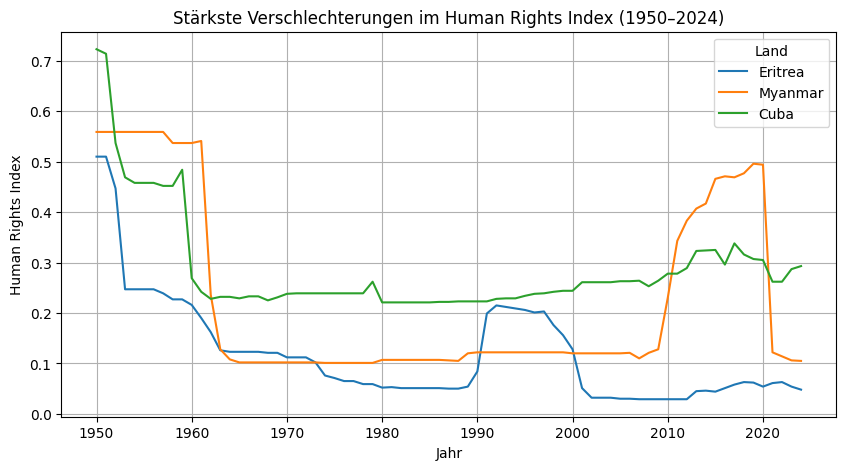

In [ ]:
pivot[laender2].plot(
    title="Stärkste Verschlechterungen im Human Rights Index (1950–2024)",
    xlabel="Jahr",
    ylabel="Human Rights Index",
    grid=True,
    figsize=(10, 5)
)


### Beschreiben der Beobachtungen
**Stärkste Verbesserungen des Human Rights Index**
- Estonia
- Latvia
- Lithuanian


**Stärkste Verschlechterungen des Human Rights Index**
- Erithrea
- Myanmar
- Cuba

### Interpretation der Resultate (Hypothesen zu den Resultaten)


### Untermauern der Interpretation mittels Hinweise zur Literatur (Mögliche Zusammenhänge aufzeigen).